In [1]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import numpy as np
import re
import time

In [2]:
headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:106.0) Gecko/20100101 Firefox/106.0',
}

## Helper: Get review links (exclude comical/funky/gallery)

In [3]:
def get_links(url):
    page = requests.get(url, headers=headers)
    soup = BeautifulSoup(page.text, 'html.parser')
    links = []
    for a in soup.find_all('a', href=True):
        href  = a['href']
        title = a.get_text(strip=True)
        if not ('/reviews/' in href and href.endswith('.html')):
            continue
        if 'gallery' in href:
            continue
        if re.search(r'comical|funky review in slides', title, re.I):
            continue
        if href not in links:
            links.append(href)
    return links

## Core scraper — reads `<strong>` tags directly from HTML

In [4]:
def get_field_from_strong(soup, *keys):
    for strong in soup.find_all('strong'):
        strong_text = strong.get_text(strip=True)
        for key in keys:
            if re.match(rf'^{re.escape(key)}\s*:?$', strong_text, re.I):
                val = ''
                for sibling in strong.next_siblings:
                    if isinstance(sibling, str):
                        val += sibling
                    elif sibling.name in ['br', 'p']:
                        break
                    else:
                        t = sibling.get_text()
                        if t and sibling.name != 'a':
                            val += t
                val = val.strip().lstrip(':').strip()
                if val:
                    return val
                parent_text = strong.parent.get_text()
                for key2 in keys:
                    m = re.search(rf'{re.escape(key2)}\s*:\s*(.+)', parent_text, re.I)
                    if m:
                        return m.group(1).strip()
    return np.nan


def scrape_review(url):
    try:
        resp = requests.get(url, headers=headers, timeout=10)
        soup = BeautifulSoup(resp.text, 'html.parser')

        # Content type — check ALL possible web series label variations
        content_type = 'Movie'
        for strong in soup.find_all('strong'):
            strong_text = strong.get_text(strip=True).lower()
            if re.search(r'web\s*series', strong_text, re.I):
                content_type = 'Web Series'
                break

        # ... rest of your scrape_review function

        # Title
        title = get_field_from_strong(soup, 'Movie Name', 'Web Series Name')
        if pd.isna(title):
            h1 = soup.find('h1')
            if h1:
                t = h1.get_text(strip=True)
                t = re.sub(r'^(OTT\s+)?Review\s*[:\s]+', '', t, flags=re.I)
                title = t.split(' – ')[0].split(' - ')[0].strip()

        # Release Date / Streaming Date -> one column
        raw_date = get_field_from_strong(soup, 'Release Date', 'Streaming Date')
        release_date = np.nan
        if not pd.isna(raw_date):
            m = re.search(r'([A-Za-z]+ \d+,?\s*\d{4})', str(raw_date))
            if m:
                release_date = m.group(1).strip()
            else:
                release_date = str(raw_date).strip()

        # Rating
        rating     = np.nan
        rating_str = np.nan
        full_text = soup.get_text()
        m = re.search(r'123telugu\.com\s+Rating\s*:\s*(\d+\.?\d*)\s*/\s*5', full_text, re.I)
        if m:
            rating     = float(m.group(1))
            rating_str = f"{m.group(1)}/5"

        # Cast & Crew
        starring   = get_field_from_strong(soup, 'Starring')
        director   = get_field_from_strong(soup, 'Director')
        producer   = get_field_from_strong(soup, 'Producer', 'Producers')
        music_dir  = get_field_from_strong(soup, 'Music Director')
        cinematog  = get_field_from_strong(soup, 'Cinematographer')
        editor     = get_field_from_strong(soup, 'Editor')

        # Review Type
        review_type = 'Theatrical'
        h1 = soup.find('h1')
        h1_text = h1.get_text() if h1 else ''
        if 'OTT' in h1_text or not pd.isna(get_field_from_strong(soup, 'Streaming Platform')):
            review_type = 'OTT'

        return {
            'Title'           : title,
            'Content_Type'    : content_type,
            'Review_Type'     : review_type,
            'Release_Date'    : release_date,
            'Rating'          : rating,
            'Rating_Out_Of_5' : rating_str,
            'Starring'        : starring,
            'Director'        : director,
            'Producer'        : producer,
            'Music_Director'  : music_dir,
            'Cinematographer' : cinematog,
            'Editor'          : editor,
            'Review_URL'      : url
        }

    except Exception as e:
        return {k: np.nan for k in [
            'Title','Content_Type','Review_Type','Release_Date',
            'Rating','Rating_Out_Of_5','Starring','Director',
            'Producer','Music_Director','Cinematographer',
            'Editor','Review_URL'
        ]}


In [5]:
# ── Test on 2 URLs — confirm all fields populate correctly
tests = [
    "https://www.123telugu.com/reviews/pawan-kalyans-ustaad-bhagat-singh-movie-review-and-rating.html",
    "https://www.123telugu.com/reviews/ranveer-singhs-dhurandhar-the-revenge-movie-review-and-rating.html",
]
for u in tests:
    r = scrape_review(u)
    for k, v in r.items():
        if k != 'Review_URL':
            print(f"  {k}: {v}")
    print()
    time.sleep(0.5)

  Title: Ustaad Bhagat Singh
  Content_Type: Movie
  Review_Type: Theatrical
  Release_Date: Mar 19, 2026
  Rating: 2.75
  Rating_Out_Of_5: 2.75/5
  Starring: Pawan Kalyan, Sreeleela, Raashii Khanna, Parthiban, Rao Ramesh, KS Ravikumar, and others
  Director: Harish Shankar.S
  Producer: Naveen Yerneni, Ravi Shankar Yalamanchili
  Music_Director: Devi Sri Prasad and Thaman
  Cinematographer: Ayanaka Bose
  Editor: Karthika Srinivas

  Title: Dhurandhar The Revenge
  Content_Type: Movie
  Review_Type: Theatrical
  Release_Date: Mar 19, 2026
  Rating: 3.75
  Rating_Out_Of_5: 3.75/5
  Starring: Ranveer Singh, Sanjay Dutt, R. Madhavan, Arjun Rampal, Sara Arjun
  Director: Aditya Dhar
  Producer: Aditya Dhar, Jyoti Deshpande, Lokesh Dhar
  Music_Director: Shashwat Sachdev
  Cinematographer: Vikash Nowlakha
  Editor: Shivkumar V. Panicker



## Page 1 — collect & scrape

In [6]:
review_links = get_links("https://www.123telugu.com/category/reviews/")
print(f"Page 1: {len(review_links)} links")

data1 = []
for link in review_links:
    data1.append(scrape_review(link))
    time.sleep(0.3)

df = pd.DataFrame(data1)
df

Page 1: 25 links


,Title,Content_Type,Review_Type,Release_Date,Rating,Rating_Out_Of_5,Starring,Director,Producer,Music_Director,Cinematographer,Editor,Review_URL
0,Love Insurance Kompany,Movie,Theatrical,"April 10, 2026",2.50,2.5/5,"Pradeep Ranganathan, SJ Suryah, Krithi Shetty,...",Vignesh Shivan,"Nayanthara, S.S. Lalit Kumar",Anirudh Ravichander,Ravi Varman,Pradeep E Ragav,https://www.123telugu.com/reviews/pradeep-rang...
1,Dacoit,Movie,Theatrical,"April 10, 2026",3.25,3.25/5,"Adivi Sesh, Mrunal Thakur, Anurag Kashyap, Pra...",Shaneil Deo,Supriya Yarlagadda,Bheems Ceciroleo,Danush Bhaskar,Kodati Pavan Kalyan,https://www.123telugu.com/reviews/adivi-sesh-d...
2,Biker,Movie,Theatrical,"April 03, 2026",3.25,3.25/5,"Sharwanand, Dr Rajashekhar, Malvika Nair & Oth...",Abhilash Reddy,"Vamsi Krishna Reddy, Pramodh Uppalapati",Ghibran Vaibodha,J Yuvraj,Anil Pasala,https://www.123telugu.com/reviews/sharwanand-b...
3,Raakaasaa,Movie,Theatrical,"April 03, 2026",3.00,3/5,"Sangeeth Shobhan, Nayan Sarika, Vennela Kishor...",Manasa Sharma,Niharika Konidela & Umesh Kumar Bansal,Anudeep Dev,Raju Edurolu,Anwar Ali,https://www.123telugu.com/reviews/raakaasaa-te...
4,Kaattaan,Web Series,OTT,"March 27, 2026",2.25,2.25/5,"Vijay Sethupathi, Milind Soman, Sudev Nair, VJ...",M.Manikandan & B.Ajithkumar,Vijay Sethupathi,Rajesh Murugesan,"Madhu Neelakandan, Shanmuga Sundaram",B.Ajithkumar,https://www.123telugu.com/reviews/vijay-sethup...
5,YOUTH,Movie,Theatrical,"Mar 27, 2026",3.00,3/5,"Ken Karunas, Anishma Anilkumar, Suraj Venjaram...",Ken Karunas,"Karuppiah C. Ram, Sulochana Kumar",G.V. Prakash Kumar,Viki,Nash,https://www.123telugu.com/reviews/ken-karunas-...
6,Happy Raj,Movie,Theatrical,"Mar 27, 2026",2.75,2.75/5,"GV Prakash, Abbas, Sri Gouri Priya, George Mar...",Maria Raja Elanchezian,Jaivarda,Justin Prabhakaran,Madhan Chirstopher,Selva RK,https://www.123telugu.com/reviews/g-v-prakash-...
7,Band Melam,Movie,Theatrical,"Mar 26, 2026",2.25,2.25/5,"Harsh Roshan, Sridevi, Sai Kumar & Others.",Sathish Javvaji,"Kavya, Shravya",Vijai Bulganin,Satish Mutyala,Siva Mupparaju,https://www.123telugu.com/reviews/band-melam-m...
8,Ustaad Bhagat Singh,Movie,Theatrical,"Mar 19, 2026",2.75,2.75/5,"Pawan Kalyan, Sreeleela, Raashii Khanna, Parth...",Harish Shankar.S,"Naveen Yerneni, Ravi Shankar Yalamanchili",Devi Sri Prasad and Thaman,Ayanaka Bose,Karthika Srinivas,https://www.123telugu.com/reviews/pawan-kalyan...
9,Dhurandhar The Revenge,Movie,Theatrical,"Mar 19, 2026",3.75,3.75/5,"Ranveer Singh, Sanjay Dutt, R. Madhavan, Arjun...",Aditya Dhar,"Aditya Dhar, Jyoti Deshpande, Lokesh Dhar",Shashwat Sachdev,Vikash Nowlakha,Shivkumar V. Panicker,https://www.123telugu.com/reviews/ranveer-sing...


## Page 2 — collect & scrape

In [7]:
review_links2 = get_links("https://www.123telugu.com/category/reviews/page/2/")
print(f"Page 2: {len(review_links2)} links")

data2 = []
for link in review_links2:
    data2.append(scrape_review(link))
    time.sleep(0.3)

df2 = pd.DataFrame(data2)
df2

Page 2: 23 links


,Title,Content_Type,Review_Type,Release_Date,Rating,Rating_Out_Of_5,Starring,Director,Producer,Music_Director,Cinematographer,Editor,Review_URL
0,Funky,Movie,Theatrical,"Feb 13, 2026",2.50,2.5/5,"Vishwak Sen, Kayadu Lohar, Naresh, VTV Ganesh,...",Anudeep KV,Naga Vamsi S – Sai Soujanya,Bheems Ceciroleo,Suresh Sarangam,Navin Nooli,https://www.123telugu.com/reviews/vishwak-sen-...
1,O Romeo,Movie,Theatrical,"Feb 13, 2026",2.50,2.5/5,"Shahid Kapoor,Triptii Dimri ,Avinash Tiwary,Fa...",Vishal Bhardwaj,Sajid Nadiadwala,Shankar-Ehsaan-Loy,"Ben Bernhard, BVK",Praveen Prabhakar,https://www.123telugu.com/reviews/shahid-kapoo...
2,Parasakthi,Movie,OTT,"Feb 07, 2026",2.50,2.5/5,"Sivakarthikeyan, Ravi Mohan, Atharvaa, Sreeleela",Sudha Kongara,Aakash Baskaran,G.V. Prakash,Ravi K. Chandran,Sathish Suriya,https://www.123telugu.com/reviews/sivakarthike...
3,With Love,Movie,Theatrical,"Feb 06, 2026",3.00,3/5,"Abishan Jeevinth, Anaswara Rajan, Harish Kumar...",Madhan,Soundarya Rajinikanth & Magesh Raj Pasilian,Sean Roldan,Santhosh,Suresh Kumar,https://www.123telugu.com/reviews/with-love-mo...
4,Euphoria,Movie,Theatrical,"Feb 06, 2026",2.75,2.75/5,"Bhumika Chawla, Sara Arjun, Nassar, Rohith, Vi...",Gunasekhar,Ragini Guna,Kaala Bhairava,Praveen K Pothan,Prawin Pudi,https://www.123telugu.com/reviews/gunasekhars-...
5,Sri Chidambaram Garu,Movie,Theatrical,"Feb 06, 2026",2.50,2.5/5,"Vamsi Tummala, Sandhya Vasishta, Gopinath, Siv...",Vinay Ratnam,"Chinta Vineesha Reddy, Chinta Gopala Krishna R...",Chandu Ravi,Shravan Muppiri,Anwar Ali,https://www.123telugu.com/reviews/sri-chidamba...
6,Om Shanti Shanti Shantihi,Movie,Theatrical,"Jan 30, 2026",2.75,2.75/5,"Tharun Bhascker Dhaassyam, Eesha Rebba, Brahma...",A R Sajeev,"Srujan Yarabolu, Aditya Pittie, Vivek Krishnan...",Jay Krish,Deepak Yaragera,AR Sajeev,https://www.123telugu.com/reviews/tharun-bhasc...
7,Gandhi Talks,Movie,Theatrical,"Jan 30, 2026",2.75,2.75/5,"Vijay Sethupathi, Arvind Swami, Aditi Rao Hyda...",Kishor Pandurang ‘Belekar’,"Rajesh Kejriwal, Gurpal Sachar",A. R. Rahman,Karan B. Rawat,Ashish Mhatre,https://www.123telugu.com/reviews/vijay-sethup...
8,Sarvam Maya,Movie,OTT,"Jan 30, 2026",3.25,3.25/5,"Nivin Pauly, Aju Varghese, Riya Shibu, Janardh...",Akhil Sathyan,Dr. Ajayya Kumar and Rajeev Menon,Justin Prabhakaran,Sharan Velayudhan,NaN,https://www.123telugu.com/reviews/nivin-paulys...
9,Annagaru Vostaru,Movie,OTT,"Jan 28, 2026",2.50,2.5/5,"Karthi, Krithi Shetty, Sathyaraj, Rajkiran, An...",Nalan Kumarasamy,K.E.Gnanavelraja,Santhosh Narayanan,George C. Williams Isc,Vetre Krishnan,https://www.123telugu.com/reviews/karthis-anna...


## Pages 3–20 — bulk (400+ rows)

In [8]:
all_links = []
for i in range(3, 21):
    url = f"https://www.123telugu.com/category/reviews/page/{i}/"
    print(url)
    all_links += get_links(url)
    time.sleep(0.5)

all_links = list(set(all_links))
print(f"\nTotal unique links pages 3–20: {len(all_links)}")

https://www.123telugu.com/category/reviews/page/3/
https://www.123telugu.com/category/reviews/page/4/
https://www.123telugu.com/category/reviews/page/5/
https://www.123telugu.com/category/reviews/page/6/
https://www.123telugu.com/category/reviews/page/7/
https://www.123telugu.com/category/reviews/page/8/
https://www.123telugu.com/category/reviews/page/9/
https://www.123telugu.com/category/reviews/page/10/
https://www.123telugu.com/category/reviews/page/11/
https://www.123telugu.com/category/reviews/page/12/
https://www.123telugu.com/category/reviews/page/13/
https://www.123telugu.com/category/reviews/page/14/
https://www.123telugu.com/category/reviews/page/15/
https://www.123telugu.com/category/reviews/page/16/
https://www.123telugu.com/category/reviews/page/17/
https://www.123telugu.com/category/reviews/page/18/
https://www.123telugu.com/category/reviews/page/19/
https://www.123telugu.com/category/reviews/page/20/

Total unique links pages 3–20: 494


In [9]:
data3 = []
for link in all_links:
    data3.append(scrape_review(link))
    time.sleep(0.3)

df3 = pd.DataFrame(data3)
print(df3.shape)
df3

(494, 13)


,Title,Content_Type,Review_Type,Release_Date,Rating,Rating_Out_Of_5,Starring,Director,Producer,Music_Director,Cinematographer,Editor,Review_URL
0,Thandel,Movie,Theatrical,"February 07, 2025",3.25,3.25/5,"Naga Chaitanya, Sai Pallavi & Others",Chandoo Mondeti,Bunny Vas,Devi Sri Prasad,Shamdat (ISC),NaN,https://www.123telugu.com/reviews/naga-chaitan...
1,Drinker Sai,Movie,Theatrical,NaN,2.50,2.5/5,"Dharma, Aishwarya Sharma, Posani Krishnamurali...",Kiran Tirumalasetti,"Basavaraju Srinivas, Ismail shaik & Basavaraju...",Sri Vasanth,Prasanth Ankireddy,Marthand K. Venkatesh,https://www.123telugu.com/reviews/drinker-sai-...
2,Double iSmart,Movie,Theatrical,"August 15, 2024",2.75,2.75/5,"Ram Pothineni, Kavya Thapar, Sanjay Dutt, Getu...",Puri Jagannadh,"Puri Jagannadh, Charmme Kaur",Mani Sharma,"Gianni Giannelli, Shyam K. Naidu",Karthika Sreenivas R,https://www.123telugu.com/reviews/double-ismar...
3,Devil,Movie,Theatrical,"December 29, 2023",3.00,3/5,"Nandamuri Kalyan Ram, Samyukta Menon, Malvika ...",Abhishek Nama,Abhishek Nama,Harshavardhan Rameshwar,Soundar Rajan S,Tammiraju,https://www.123telugu.com/reviews/devil-telugu...
4,Logout,Movie,OTT,"April 18, 2025",3.00,3/5,"Babil Khan, Rasika Dugal, Gandharv Dewan, Nimi...",Amit Golani,"Sameer Saxena, Vipin Agnihotri",NaN,Pooja S Gupte,NaN,https://www.123telugu.com/reviews/logout-ott-m...
...,...,...,...,...,...,...,...,...,...,...,...,...,...
489,Bade Miyan Chote Miyan,Movie,Theatrical,"April 11, 2024",2.50,2.5/5,"Akshay Kumar, Tiger Shroff, Prithviraj Sukumar...",Ali Abbas Zafar,"Vashu Bhagnani, Jackky Bhagnani, Ali Abbas Zaf...",Vishal Mishra,Marcin Laskawiec,Steven Bernard,https://www.123telugu.com/reviews/bade-miyan-c...
490,Demon Slayer-Infinity Castle,Movie,Theatrical,"Sep 12, 2025",3.00,3/5,NaN,Haruo Sotozaki,"Akifumi Fujio, Masanori Miyake, Yūma Takahashi",NaN,Yūichi Terao,Manabu Kamino,https://www.123telugu.com/reviews/demon-slayer...
491,The Mystery of Moksha Island,Movie,OTT,"September 20, 2024",2.75,2.75/5,"Nandhu, Priya Anand, Ashutosh Rana, Akshara Go...",Anish Yohan Kuruvilla,"Ram Achanta, Gopi Achanta",Shakti Kanth Karthik,Naveen Yadav,NaN,https://www.123telugu.com/reviews/the-mystery-...
492,The Old Guard 2,Movie,OTT,"July 2, 2025",2.75,2.75/5,"Henry Golding, Veronica Ngo, Charlize Theron, ...",Victoria Mahoney,"David Ellison, Dana Goldberg, Don Granger, Cha...",NaN,Barry Ackroyd,Matthew Schmidt,https://www.123telugu.com/reviews/ott-review-t...


### Final DataFrame

In [10]:
final_df = pd.concat([df, df2, df3], ignore_index=True)
final_df.drop_duplicates(subset='Review_URL', inplace=True)
final_df.reset_index(drop=True, inplace=True)
print(final_df.shape)
final_df

(538, 13)


,Title,Content_Type,Review_Type,Release_Date,Rating,Rating_Out_Of_5,Starring,Director,Producer,Music_Director,Cinematographer,Editor,Review_URL
0,Love Insurance Kompany,Movie,Theatrical,"April 10, 2026",2.50,2.5/5,"Pradeep Ranganathan, SJ Suryah, Krithi Shetty,...",Vignesh Shivan,"Nayanthara, S.S. Lalit Kumar",Anirudh Ravichander,Ravi Varman,Pradeep E Ragav,https://www.123telugu.com/reviews/pradeep-rang...
1,Dacoit,Movie,Theatrical,"April 10, 2026",3.25,3.25/5,"Adivi Sesh, Mrunal Thakur, Anurag Kashyap, Pra...",Shaneil Deo,Supriya Yarlagadda,Bheems Ceciroleo,Danush Bhaskar,Kodati Pavan Kalyan,https://www.123telugu.com/reviews/adivi-sesh-d...
2,Biker,Movie,Theatrical,"April 03, 2026",3.25,3.25/5,"Sharwanand, Dr Rajashekhar, Malvika Nair & Oth...",Abhilash Reddy,"Vamsi Krishna Reddy, Pramodh Uppalapati",Ghibran Vaibodha,J Yuvraj,Anil Pasala,https://www.123telugu.com/reviews/sharwanand-b...
3,Raakaasaa,Movie,Theatrical,"April 03, 2026",3.00,3/5,"Sangeeth Shobhan, Nayan Sarika, Vennela Kishor...",Manasa Sharma,Niharika Konidela & Umesh Kumar Bansal,Anudeep Dev,Raju Edurolu,Anwar Ali,https://www.123telugu.com/reviews/raakaasaa-te...
4,Kaattaan,Web Series,OTT,"March 27, 2026",2.25,2.25/5,"Vijay Sethupathi, Milind Soman, Sudev Nair, VJ...",M.Manikandan & B.Ajithkumar,Vijay Sethupathi,Rajesh Murugesan,"Madhu Neelakandan, Shanmuga Sundaram",B.Ajithkumar,https://www.123telugu.com/reviews/vijay-sethup...
...,...,...,...,...,...,...,...,...,...,...,...,...,...
533,Bade Miyan Chote Miyan,Movie,Theatrical,"April 11, 2024",2.50,2.5/5,"Akshay Kumar, Tiger Shroff, Prithviraj Sukumar...",Ali Abbas Zafar,"Vashu Bhagnani, Jackky Bhagnani, Ali Abbas Zaf...",Vishal Mishra,Marcin Laskawiec,Steven Bernard,https://www.123telugu.com/reviews/bade-miyan-c...
534,Demon Slayer-Infinity Castle,Movie,Theatrical,"Sep 12, 2025",3.00,3/5,NaN,Haruo Sotozaki,"Akifumi Fujio, Masanori Miyake, Yūma Takahashi",NaN,Yūichi Terao,Manabu Kamino,https://www.123telugu.com/reviews/demon-slayer...
535,The Mystery of Moksha Island,Movie,OTT,"September 20, 2024",2.75,2.75/5,"Nandhu, Priya Anand, Ashutosh Rana, Akshara Go...",Anish Yohan Kuruvilla,"Ram Achanta, Gopi Achanta",Shakti Kanth Karthik,Naveen Yadav,NaN,https://www.123telugu.com/reviews/the-mystery-...
536,The Old Guard 2,Movie,OTT,"July 2, 2025",2.75,2.75/5,"Henry Golding, Veronica Ngo, Charlize Theron, ...",Victoria Mahoney,"David Ellison, Dana Goldberg, Don Granger, Cha...",NaN,Barry Ackroyd,Matthew Schmidt,https://www.123telugu.com/reviews/ott-review-t...


## Data Cleaning

In [11]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 538 entries, 0 to 537
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Title            538 non-null    object 
 1   Content_Type     538 non-null    object 
 2   Review_Type      538 non-null    object 
 3   Release_Date     533 non-null    object 
 4   Rating           537 non-null    float64
 5   Rating_Out_Of_5  537 non-null    object 
 6   Starring         531 non-null    object 
 7   Director         513 non-null    object 
 8   Producer         536 non-null    object 
 9   Music_Director   474 non-null    object 
 10  Cinematographer  474 non-null    object 
 11  Editor           478 non-null    object 
 12  Review_URL       538 non-null    object 
dtypes: float64(1), object(12)
memory usage: 54.8+ KB


In [12]:
final_df = final_df.fillna({
    'Director': 'Unknown',
    'Music_Director': 'Unknown',
    'Cinematographer': 'Unknown',
    'Editor': 'Unknown',
    'Starring': 'Unknown'
})

In [13]:
final_df['Release_Date'] = final_df['Release_Date'].fillna('Unknown')

In [14]:
final_df['Rating_Out_Of_5'] = final_df['Rating_Out_Of_5'].fillna('0/5')

In [15]:
final_df['Rating'] = final_df['Rating'].fillna(final_df['Rating'].median())

In [16]:
final_df['Producer'] = final_df['Producer'].fillna('Unknown')

In [17]:
final_df.isnull().sum()

,0
Title,0
Content_Type,0
Review_Type,0
Release_Date,0
Rating,0
Rating_Out_Of_5,0
Starring,0
Director,0
Producer,0
Music_Director,0


In [18]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 538 entries, 0 to 537
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Title            538 non-null    object 
 1   Content_Type     538 non-null    object 
 2   Review_Type      538 non-null    object 
 3   Release_Date     538 non-null    object 
 4   Rating           538 non-null    float64
 5   Rating_Out_Of_5  538 non-null    object 
 6   Starring         538 non-null    object 
 7   Director         538 non-null    object 
 8   Producer         538 non-null    object 
 9   Music_Director   538 non-null    object 
 10  Cinematographer  538 non-null    object 
 11  Editor           538 non-null    object 
 12  Review_URL       538 non-null    object 
dtypes: float64(1), object(12)
memory usage: 54.8+ KB


## Data Analysis

In [19]:
final_df['Content_Type'].value_counts()

,count
Content_Type,
Movie,512
Web Series,26


In [20]:
final_df['Review_Type'].value_counts()

,count
Review_Type,
Theatrical,403
OTT,135


In [21]:
final_df.describe()

,Rating
count,538.000000
mean,2.666357
std,0.399572
min,1.250000
25%,2.500000
50%,2.750000
75%,3.000000
max,3.750000


## Groupby

In [22]:
final_df.groupby('Review_Type')['Rating'].agg(['min', 'mean', 'max'])

,min,mean,max
Review_Type,,,
OTT,1.50,2.738889,3.50
Theatrical,1.25,2.642060,3.75


In [23]:
final_df.groupby('Content_Type')['Rating'].agg(['min', 'mean', 'max'])

,min,mean,max
Content_Type,,,
Movie,1.25,2.658691,3.75
Web Series,1.50,2.817308,3.50


### Highest Rated Movie

In [24]:
final_df[final_df['Rating'] == final_df['Rating'].max()]

,Title,Content_Type,Review_Type,Release_Date,Rating,Rating_Out_Of_5,Starring,Director,Producer,Music_Director,Cinematographer,Editor,Review_URL
9,Dhurandhar The Revenge,Movie,Theatrical,"Mar 19, 2026",3.75,3.75/5,"Ranveer Singh, Sanjay Dutt, R. Madhavan, Arjun...",Aditya Dhar,"Aditya Dhar, Jyoti Deshpande, Lokesh Dhar",Shashwat Sachdev,Vikash Nowlakha,Shivkumar V. Panicker,https://www.123telugu.com/reviews/ranveer-sing...


### Top Rated WebSeries


In [25]:
ott_reviews = final_df[final_df['Content_Type'] == 'Web Series']
highest_ott_rating = ott_reviews[ott_reviews['Rating'] == ott_reviews['Rating'].max()]

highest_ott_rating[['Title','Rating','Rating_Out_Of_5','Content_Type','Review_Type']]

,Title,Rating,Rating_Out_Of_5,Content_Type,Review_Type
173,Stranger Things 5 & Final Episode,3.5,3.5/5,Web Series,OTT
234,Mayasabha,3.5,3.5/5,Web Series,OTT


### Low Rated (< 2/5)

In [26]:
final_df[(final_df['Rating'] > 0) & (final_df['Rating'] < 2.0)][['Title','Rating','Rating_Out_Of_5','Content_Type','Review_Type']]

,Title,Rating,Rating_Out_Of_5,Content_Type,Review_Type
131,Rambo in Love,1.50,1.5/5,Movie,OTT
151,Happy Ending,1.50,1.5/5,Movie,Theatrical
214,Chitram Choodara,1.50,1.5/5,Movie,OTT
269,Lambasingi,1.50,1.5/5,Movie,Theatrical
277,Saaree,1.25,1.25/5,Movie,Theatrical
295,Prema Katha,1.75,1.75/5,Movie,Theatrical
331,MukhyaGamanika,1.50,1.5/5,Movie,Theatrical
335,Bloody Ishq,1.75,1.75/5,Movie,OTT
336,RGV’s Shapadham,1.75,1.75/5,Movie,Theatrical
337,Viraatapalem-PC Meena Reporting,1.50,1.5/5,Web Series,OTT


## Visualizations

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

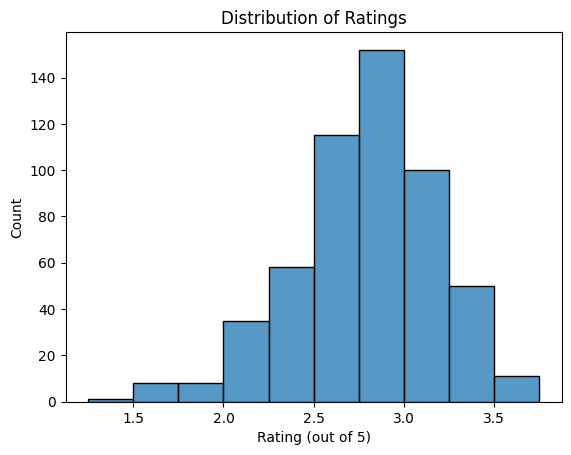

In [28]:
# Rating distribution
sns.histplot(final_df[final_df['Rating'] > 0]['Rating'], bins=10)
plt.title('Distribution of Ratings')
plt.xlabel('Rating (out of 5)')
plt.ylabel('Count')
plt.show()

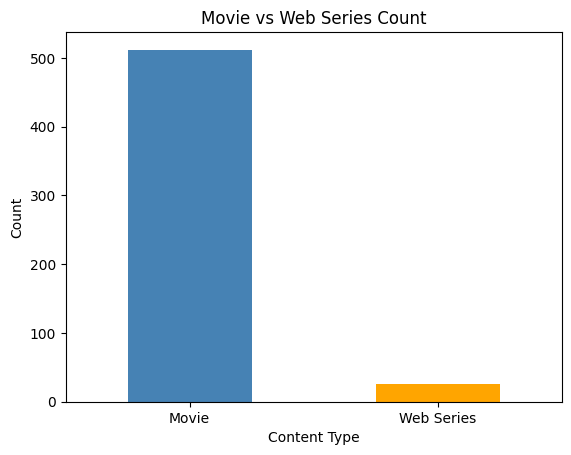

In [29]:
# Movie vs Web Series count
final_df['Content_Type'].value_counts().plot(kind='bar', color=['steelblue','orange'])
plt.title('Movie vs Web Series Count')
plt.xlabel('Content Type')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

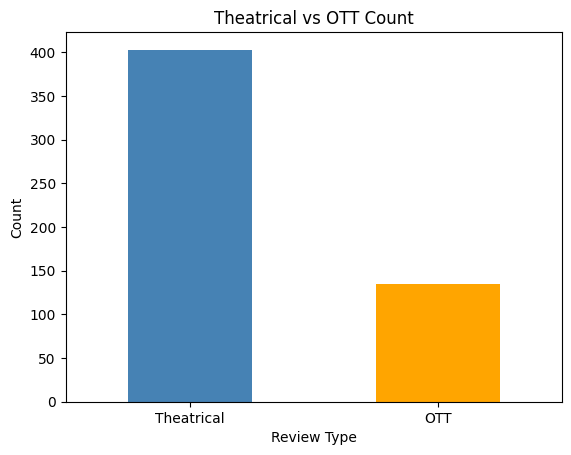

In [30]:
# Theatrical vs OTT count
final_df['Review_Type'].value_counts().plot(kind='bar', color=['steelblue','orange'])
plt.title('Theatrical vs OTT Count')
plt.xlabel('Review Type')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

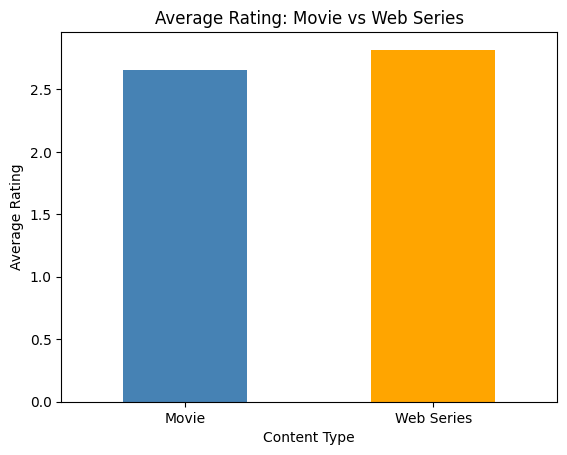

In [31]:
# Average rating: Movie vs Web Series
final_df[final_df['Rating'] > 0].groupby('Content_Type')['Rating'].mean().plot(kind='bar', color=['steelblue','orange'])
plt.title('Average Rating: Movie vs Web Series')
plt.xlabel('Content Type')
plt.ylabel('Average Rating')
plt.xticks(rotation=0)
plt.show()

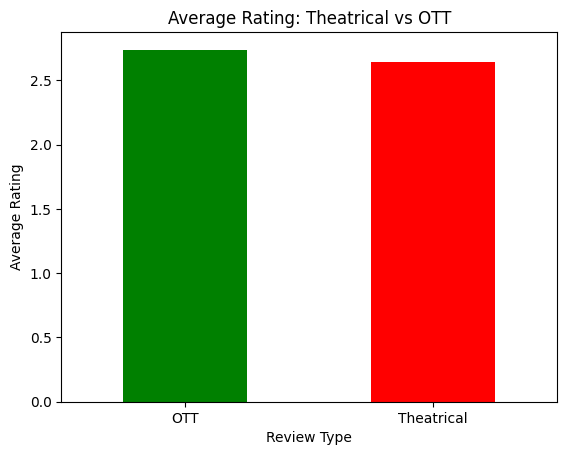

In [32]:
# Average rating: Theatrical vs OTT
final_df[final_df['Rating'] > 0].groupby('Review_Type')['Rating'].mean().plot(kind='bar', color=['green','red'])
plt.title('Average Rating: Theatrical vs OTT')
plt.xlabel('Review Type')
plt.ylabel('Average Rating')
plt.xticks(rotation=0)
plt.show()

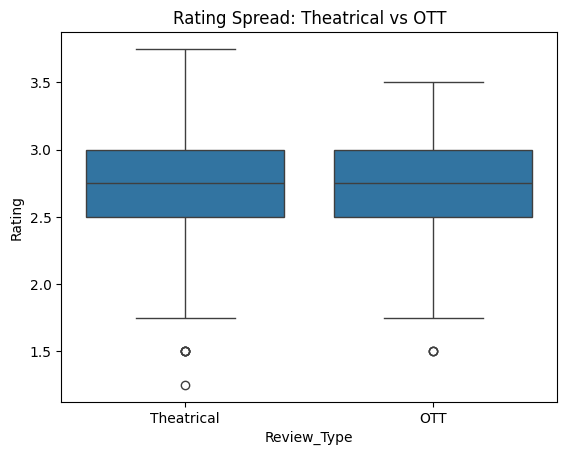

In [33]:
# Boxplot
sns.boxplot(x='Review_Type', y='Rating', data=final_df[final_df['Rating'] > 0])
plt.title('Rating Spread: Theatrical vs OTT')
plt.show()